In [122]:
import pandas as pd 
import numpy as np 


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
df=pd.read_csv('D:\GUVI\MYSQL\Online_Food_Analysis (1).csv')

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_20468\2257191141.py:1: SyntaxWarning: invalid escape sequence '\G'
  df=pd.read_csv('D:\GUVI\MYSQL\Online_Food_Analysis (1).csv')


In [125]:
df.shape 
df.columns
df.info()
df.isnull().sum()/len(df)*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         100000 non-null  int64  
 3   Customer_Gender      100000 non-null  object 
 4   City                 100000 non-null  object 
 5   Area                 100000 non-null  object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         100000 non-null  object 
 9   Order_Date           100000 non-null  object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    84964 non-null   float64
 12  Distance_km          84964 non-null   float64
 13  Order_Value          100000 non-null  float64
 14  Discount_Applied     100000 non-null  int64  
 15  Final_Amount      

Order_ID                0.000
Customer_ID             0.000
Customer_Age            0.000
Customer_Gender         0.000
City                    0.000
Area                    0.000
Restaurant_ID           0.000
Restaurant_Name         0.000
Cuisine_Type            0.000
Order_Date              0.000
Order_Time              1.998
Delivery_Time_Min      15.036
Distance_km            15.036
Order_Value             0.000
Discount_Applied        0.000
Final_Amount            0.000
Payment_Mode            0.000
Order_Status            0.000
Cancellation_Reason     0.000
Delivery_Partner_ID     0.000
Delivery_Rating        15.036
Restaurant_Rating       0.000
Order_Day               0.000
Peak_Hour               0.000
Profit_Margin           0.000
Distance_Bin           15.036
dtype: float64

In [126]:
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Distance_Bin
0,ORD000001,CUST6948,19,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,20-10-2024,...,UPI,Delivered,Not_Cancelled,DP563,5.0,4.4,Weekend,True,0.13,Very_Near
1,ORD000002,CUST6515,39,Female,Chennai,North,RES689,Restaurant_419,Chinese,12-08-2024,...,COD,Delivered,Not_Cancelled,DP369,5.0,4.7,Weekday,True,0.48,Very_Far
2,ORD000003,CUST1765,39,Male,Delhi,Central,RES723,Restaurant_244,Arabian,08-12-2024,...,Wallet,Delivered,Not_Cancelled,DP580,4.0,4.9,Weekend,True,0.08,Medium
3,ORD000004,CUST2744,39,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,08-10-2024,...,Order Cancelled,Cancelled,Late Delivery,DP155,NaN,3.4,Weekday,True,0.04,NaN
4,ORD000005,CUST4389,57,Female,Chennai,South,RES419,Restaurant_262,Chinese,04-02-2024,...,Card,Delivered,Not_Cancelled,DP728,2.0,4.4,Weekend,False,0.12,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,39,Unknown,Mumbai,East,RES295,Restaurant_500,Arabian,10-06-2024,...,Card,Delivered,Not_Cancelled,DP835,2.0,4.0,Weekday,True,0.17,Medium
99996,ORD099997,CUST6158,39,Male,Mumbai,East,RES157,Restaurant_458,Arabian,22-04-2024,...,COD,Delivered,Not_Cancelled,DP476,4.0,3.5,Weekday,False,-0.15,Medium
99997,ORD099998,CUST2155,39,Unknown,Delhi,East,RES287,Restaurant_273,Mexican,23-02-2024,...,Order Cancelled,Cancelled,Late Delivery,DP577,NaN,4.0,Weekday,True,0.47,NaN
99998,ORD099999,CUST3015,39,Female,Delhi,North,RES491,Restaurant_241,Mexican,10-12-2024,...,Wallet,Delivered,Not_Cancelled,DP896,3.0,4.3,Weekday,False,0.44,Near


In [127]:
#Order Day Type (Weekday / Weekend)
df['Order_Date']=pd.to_datetime(df['Order_Date'])
df['Day_Name'] = df['Order_Date'].dt.day_name()
df['Order_Day_Type'] = df['Day_Name'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_20468\2150675687.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date']=pd.to_datetime(df['Order_Date'])


In [128]:
#Delivery Performance Categories
df['Delivery_Category'] = pd.cut(
    df['Delivery_Time_Min'],
    bins=[0, 30, 60, 500],
    labels=['Fast', 'Moderate', 'Slow']
)

In [129]:
#Profit Margin Percentage
df['Profit_Percentage']=(df['Profit_Margin']/df['Final_Amount'])*100

In [130]:
#checking distriboution
df['Restaurant_Rating'].describe()

count    100000.000000
mean          4.249680
std           0.722554
min           3.000000
25%           3.600000
50%           4.200000
75%           4.900000
max           5.500000
Name: Restaurant_Rating, dtype: float64

In [131]:
# Step 1: Remove invalid values
df.loc[
    (df['Restaurant_Rating'] > 5) | 
    (df['Restaurant_Rating'] < 0),
    'Restaurant_Rating'
] = np.nan

# Step 2: Fill with median
df['Restaurant_Rating'].fillna(
    df['Restaurant_Rating'].median(),
    inplace=True
)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_20468\1590661781.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Restaurant_Rating'].fillna(


In [132]:
#coverting cancelled order of Delivery_Time_Min NaN 
df.loc[df['Order_Status'] == 'Cancelled', 'Delivery_Time_Min'] = np.nan

In [133]:
df['Age_Group'] = pd.cut(
    df['Customer_Age'],
    bins=[17, 25, 35, 50, 100],
    labels=[
        'Young Adults (18-25)',
        'Working Professionals (26-35)',
        'Family Group (36-50)',
        'Senior Customers (50+)'
    ]
)

In [134]:
#coverting Delivery_Time_Display to time format os "h""m"
df['Delivery_Time_Display'] = pd.to_timedelta(
    df['Delivery_Time_Min'], unit='m'
).apply(
    lambda x: f"{int(x.total_seconds()//3600)}h {int((x.total_seconds()%3600)//60)}m"
    if pd.notnull(x) else "Order Cancelled"
)

In [135]:
df.groupby('Order_Status')['Profit_Margin'].count()

Order_Status
Cancelled    15036
Delivered    84964
Name: Profit_Margin, dtype: int64

In [136]:
delivered_df = df[df['Order_Status'] == 'Delivered']
delivered_df['Profit_Margin'].describe()

count    84964.000000
mean         0.150005
std          0.202011
min         -0.200000
25%         -0.020000
50%          0.150000
75%          0.320000
max          0.500000
Name: Profit_Margin, dtype: float64

In [137]:
#coverting cancelled order of Profit_Margin NaN 
df.loc[df['Order_Status'] == 'Cancelled', 'Profit_Margin'] = np.nan

In [138]:
#coverting cancelled order of Restaurant_Rating NaN 
df.loc[df['Order_Status'] == 'Cancelled', 'Restaurant_Rating'] = np.nan

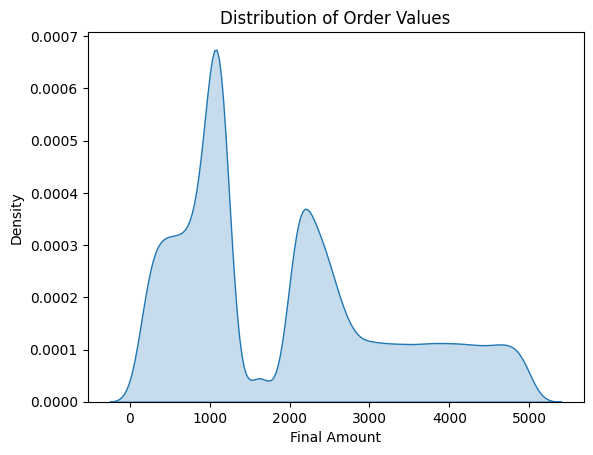

In [139]:
#Distribution of Order Values
plt.figure()
sns.kdeplot(df['Order_Value'], fill=True)

plt.title("Distribution of Order Values")
plt.xlabel("Final Amount")
plt.ylabel("Density")
plt.show()

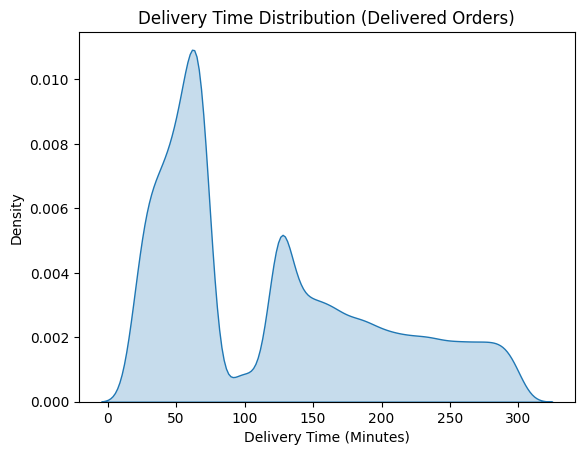

In [140]:
#Delivery Time Distribution (Only Delivered)
plt.figure()
sns.kdeplot(delivered_df['Delivery_Time_Min'], fill=True)

plt.title("Delivery Time Distribution (Delivered Orders)")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Density")
plt.show()

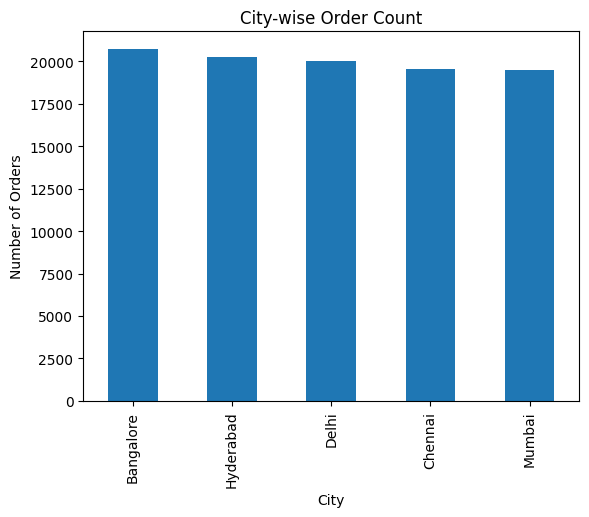

In [141]:
#City-wise Orders
city_orders = df['City'].value_counts()

plt.figure()
city_orders.plot(kind='bar')
plt.title("City-wise Order Count")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.show()

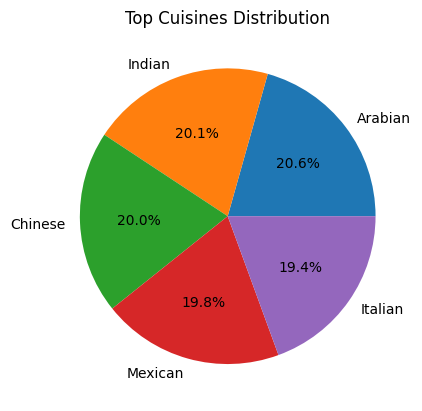

In [142]:
# cuisine-wise order analysis
top5 = df['Cuisine_Type'].value_counts().head(5)
others = df['Cuisine_Type'].value_counts().iloc[5:].sum()

final_data = top5.copy()


plt.figure()

plt.pie(
    final_data,
    labels=final_data.index,
    autopct='%1.1f%%'
)

plt.title("Top Cuisines Distribution")

plt.show()

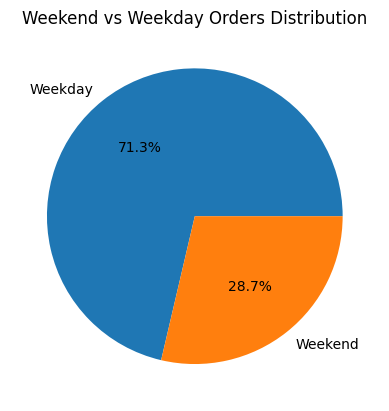

In [143]:
#Weekend vs Weekday Demand
weekend_demand = df['Order_Day_Type'].value_counts().sort_index()

plt.figure()

plt.pie(
    weekend_demand,
    labels=['Weekday', 'Weekend'],  # False = Weekday, True = Weekend
    autopct='%1.1f%%'
)

plt.title("Weekend vs Weekday Orders Distribution")

plt.show()

<Figure size 640x480 with 0 Axes>

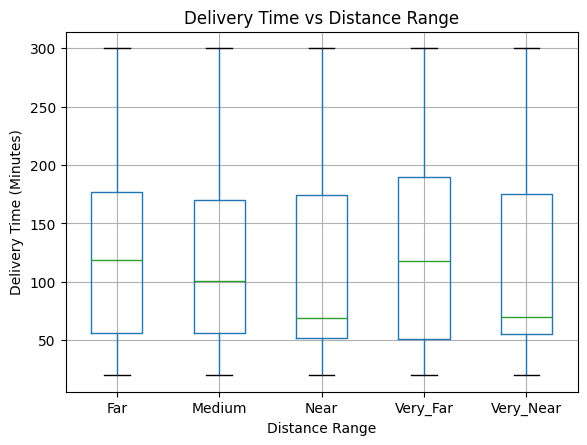

In [144]:
# Only delivered orders
delivered_df = df[df['Order_Status'] == 'Delivered']

plt.figure()

delivered_df.boxplot(
    column='Delivery_Time_Min',
    by='Distance_Bin'
)

plt.suptitle("")  # removes automatic title
plt.title("Delivery Time vs Distance Range")
plt.xlabel("Distance Range")
plt.ylabel("Delivery Time (Minutes)")

plt.show()

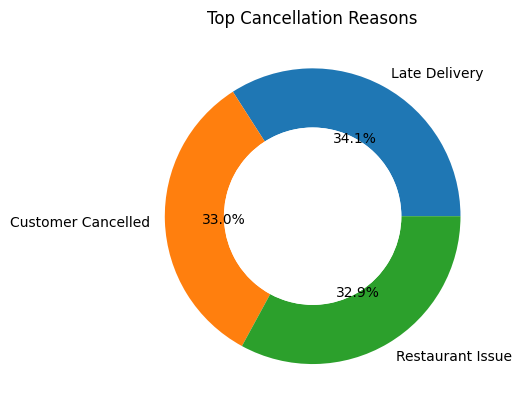

In [145]:
#Cancellation Reasons Analysis
cancel_df = df[df['Order_Status'] == 'Cancelled']
reason_counts = cancel_df['Cancellation_Reason'].value_counts()

plt.figure()

# Create donut with controlled width
plt.pie(
    reason_counts,
    labels=reason_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.4}  # controls donut thickness
)

# Add clean white center
centre_circle = plt.Circle((0, 0), 0.6, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Top Cancellation Reasons")

plt.show()

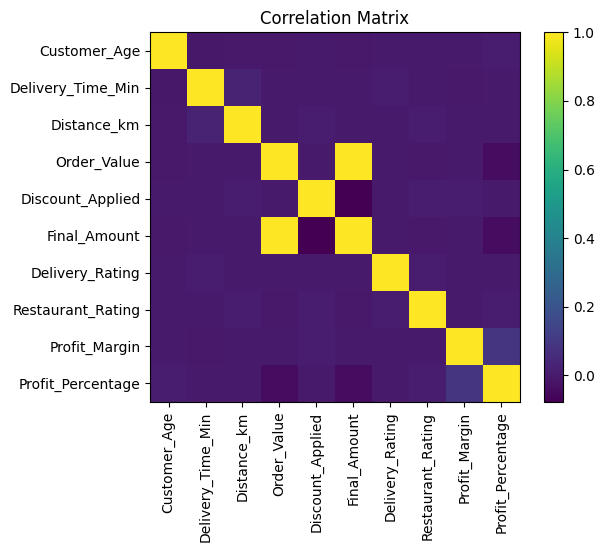

In [146]:
#Correlation Analysis (Numeric Features)
numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

In [147]:
df = df[[
    # Order Information
    'Order_ID','Order_Date','Order_Day','Day_Name','Order_Day_Type','Order_Time',
    
    # Customer Information
    'Customer_ID','Customer_Age','Age_Group','Customer_Gender',
    
    # Location
    'City','Area',
    
    # Restaurant Information
    'Restaurant_ID','Restaurant_Name','Cuisine_Type','Restaurant_Rating',
    
    # Delivery Information
    'Delivery_Partner_ID','Distance_km','Distance_Bin',
    'Delivery_Time_Min','Delivery_Time_Display','Delivery_Category',
    'Delivery_Rating',
    
    # Financial Information
    'Order_Value','Discount_Applied','Final_Amount',
    'Profit_Margin','Profit_Percentage',
    
    # Status Information
    'Payment_Mode','Order_Status','Cancellation_Reason',
    

]]

In [148]:
df.drop(columns=['Order_Time'], inplace=True)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_20468\422823003.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Order_Time'], inplace=True)


In [149]:
df.columns


Index(['Order_ID', 'Order_Date', 'Order_Day', 'Day_Name', 'Order_Day_Type',
       'Customer_ID', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Restaurant_Rating', 'Delivery_Partner_ID', 'Distance_km',
       'Distance_Bin', 'Delivery_Time_Min', 'Delivery_Time_Display',
       'Delivery_Category', 'Delivery_Rating', 'Order_Value',
       'Discount_Applied', 'Final_Amount', 'Profit_Margin',
       'Profit_Percentage', 'Payment_Mode', 'Order_Status',
       'Cancellation_Reason'],
      dtype='object')

In [150]:
#converting date format coz mysql correct format 'YYYY-MM-DD'
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_20468\2782806115.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)


In [151]:
df['Order_Date'] = df['Order_Date'].dt.strftime('%Y-%m-%d')

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_20468\1782271330.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Date'] = df['Order_Date'].dt.strftime('%Y-%m-%d')


In [152]:
df.isnull().sum()

Order_ID                     0
Order_Date                   0
Order_Day                    0
Day_Name                     0
Order_Day_Type               0
Customer_ID                  0
Customer_Age                 0
Age_Group                    0
Customer_Gender              0
City                         0
Area                         0
Restaurant_ID                0
Restaurant_Name              0
Cuisine_Type                 0
Restaurant_Rating        15036
Delivery_Partner_ID          0
Distance_km              15036
Distance_Bin             15036
Delivery_Time_Min        15036
Delivery_Time_Display        0
Delivery_Category        15036
Delivery_Rating          15036
Order_Value                  0
Discount_Applied             0
Final_Amount                 0
Profit_Margin            15036
Profit_Percentage            0
Payment_Mode                 0
Order_Status                 0
Cancellation_Reason          0
dtype: int64

In [156]:
df[['Restaurant_Rating','Distance_km','Distance_Bin','Delivery_Time_Min','Delivery_Category','Delivery_Rating']].head(5)

,Restaurant_Rating,Distance_km,Distance_Bin,Delivery_Time_Min,Delivery_Category,Delivery_Rating
0,4.4,15.75,Very_Near,187.0,Slow,5.0
1,4.7,29.50,Very_Far,20.0,Fast,5.0
2,4.9,9.90,Medium,207.0,Slow,4.0
3,0.0,0.00,NaN,0.0,NaN,0.0
4,4.4,9.60,Medium,51.0,Moderate,2.0


In [154]:
df[['Restaurant_Rating','Distance_km','Delivery_Time_Min','Delivery_Rating']] = \
df[['Restaurant_Rating','Distance_km','Delivery_Time_Min','Delivery_Rating']].fillna(0)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_20468\1388759406.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Restaurant_Rating','Distance_km','Delivery_Time_Min','Delivery_Rating']] = \


In [159]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   Order_ID               100000 non-null  object  
 1   Order_Date             100000 non-null  object  
 2   Order_Day              100000 non-null  object  
 3   Day_Name               100000 non-null  object  
 4   Order_Day_Type         100000 non-null  object  
 5   Customer_ID            100000 non-null  object  
 6   Customer_Age           100000 non-null  int64   
 7   Age_Group              100000 non-null  category
 8   Customer_Gender        100000 non-null  object  
 9   City                   100000 non-null  object  
 10  Area                   100000 non-null  object  
 11  Restaurant_ID          100000 non-null  object  
 12  Restaurant_Name        100000 non-null  object  
 13  Cuisine_Type           100000 non-null  object  
 14  Restaurant_Rating    

Order_ID                     0
Order_Date                   0
Order_Day                    0
Day_Name                     0
Order_Day_Type               0
Customer_ID                  0
Customer_Age                 0
Age_Group                    0
Customer_Gender              0
City                         0
Area                         0
Restaurant_ID                0
Restaurant_Name              0
Cuisine_Type                 0
Restaurant_Rating            0
Delivery_Partner_ID          0
Distance_km                  0
Distance_Bin             15036
Delivery_Time_Min            0
Delivery_Time_Display        0
Delivery_Category        15036
Delivery_Rating              0
Order_Value                  0
Discount_Applied             0
Final_Amount                 0
Profit_Margin            15036
Profit_Percentage            0
Payment_Mode                 0
Order_Status                 0
Cancellation_Reason          0
dtype: int64

In [161]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
print(null_counts)

Distance_Bin         15036
Delivery_Category    15036
Profit_Margin        15036
dtype: int64


In [160]:
df.to_csv("ONLINE_food_finalready.csv", index=False)